In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/Saroja/Downloads/zomato.csv", encoding='latin1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.shape

(9551, 21)

In [5]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [6]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [8]:
# Drop unnecessary column
df.drop(['Switch to order menu'], inplace= True, axis=1)

In [9]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Price range',
       'Aggregate rating', 'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [10]:
# Checking for missing values
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [11]:
#Country-wise restaurant distribution
country_count = df['Country Code'].value_counts()
country_count

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

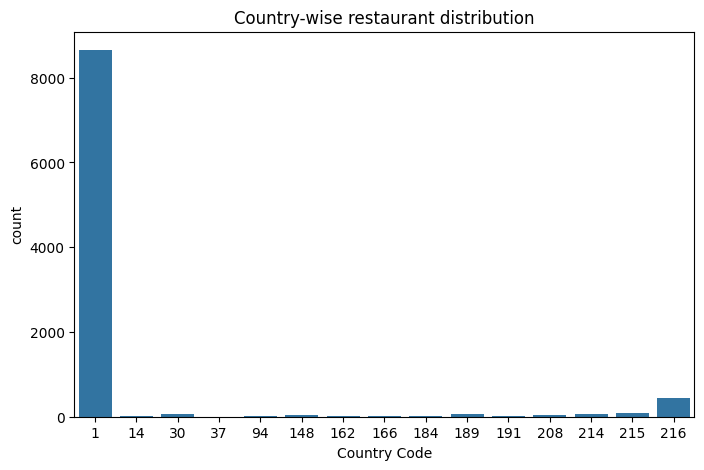

In [12]:
# Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='Country Code', data=df)
plt.title('Country-wise restaurant distribution')
plt.show()

***Insight :***
*India dominates the zomato platform*

In [13]:
# City Wise Top-10 restaurant location
df['City'].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

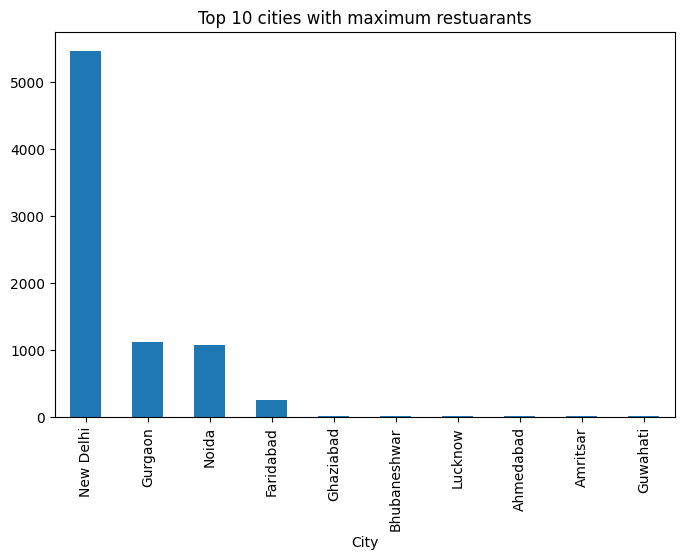

In [14]:
#Visualization
plt.figure(figsize=(8,5))
df['City'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 cities with maximum restuarants')
plt.show()

***Insight :***
*Major metros have the highest restuarant density.*

In [15]:
# Online delivery analysis
df['Has Online delivery'].value_counts()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

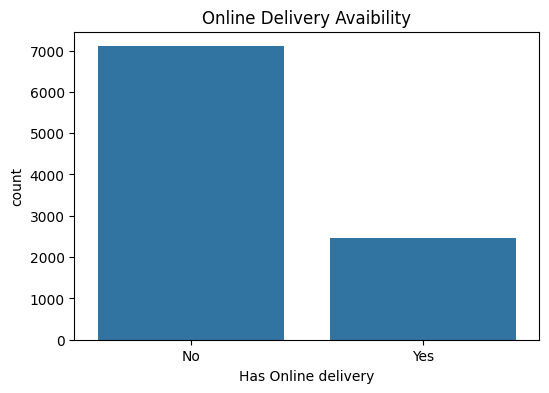

In [16]:
#Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Has Online delivery', data=df)
plt.title('Online Delivery Avaibility')
plt.show()

***Insight :***
*Most restuarants don't offer online delivery*

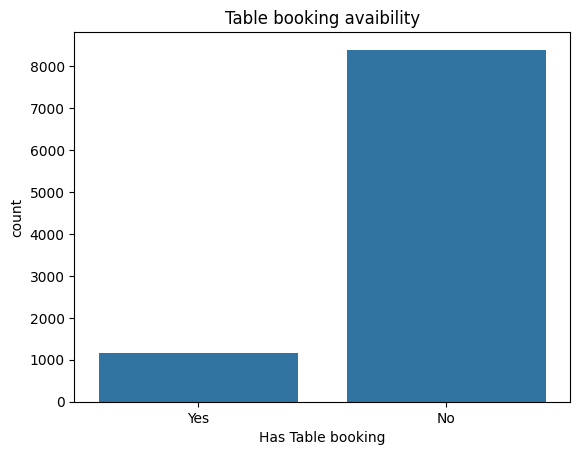

In [17]:
#Table booking analysis
sns.countplot(x="Has Table booking", data=df)
plt.title("Table booking avaibility")
plt.show()

***Insight:***
*Table booking is available in limited restuarants.*

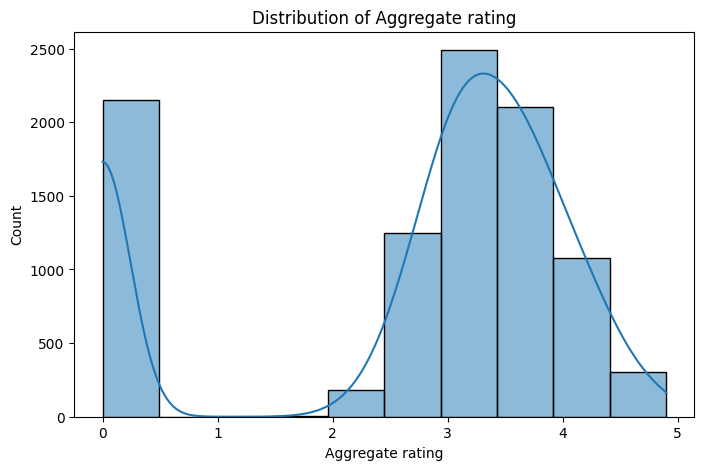

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=10, kde=True)
plt.title("Distribution of Aggregate rating")
plt.show()

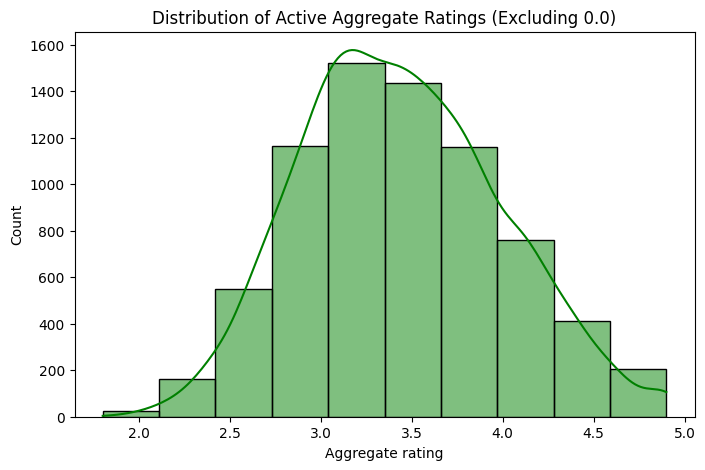

In [19]:
# Filtering out the 0.0 ratings to see the true distribution
rated_df = df[df['Aggregate rating'] > 0]

plt.figure(figsize=(8, 5))
sns.histplot(rated_df['Aggregate rating'], bins=10, kde=True, color='green')
plt.title("Distribution of Active Aggregate Ratings (Excluding 0.0)")
plt.show()

***Insight:***
*Most restaurants are rated average (3.0 to 3.8), while top scores above 4.5 are very rare.*

In [20]:
#Rating Text analysis
df['Rating text'].value_counts()

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

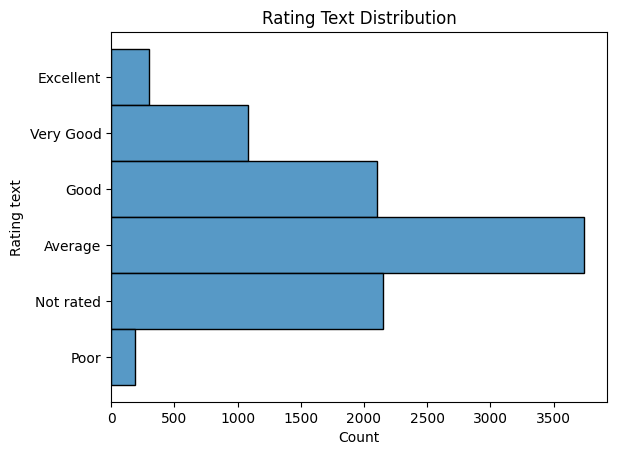

In [21]:
#Visualization
sns.histplot(y='Rating text', data=df)
plt.title('Rating Text Distribution')
plt.show()

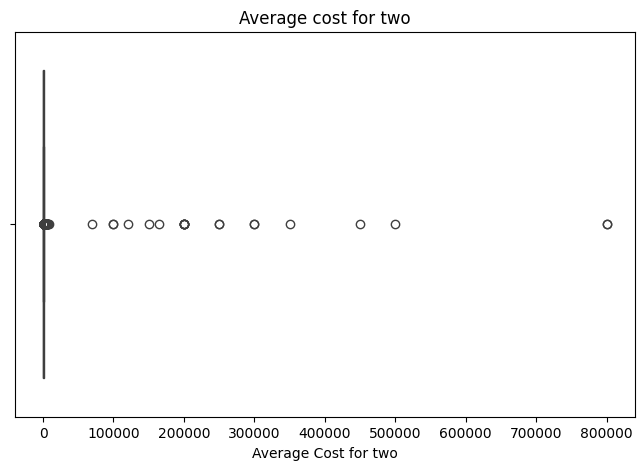

In [22]:
#Average cost for two analysis
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Average Cost for two'])
plt.title("Average cost for two")
plt.show()

***Insight:***
*Most restaurants fall under mid-price range.*

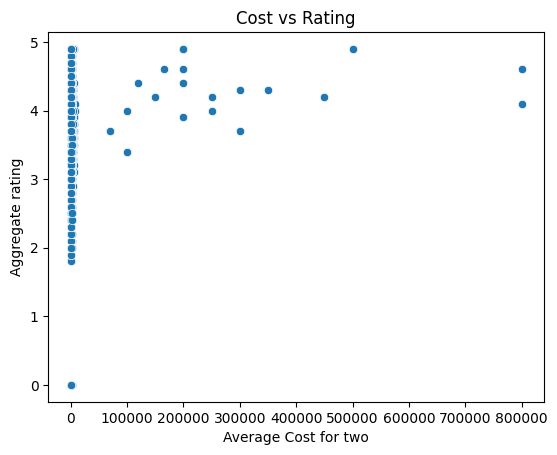

In [23]:
#Cost vs Rating Relationship
sns.scatterplot(x='Average Cost for two', y='Aggregate rating', data=df)
plt.title("Cost vs Rating")
plt.show()

***Insight:***
*Higher cost doesn't gaurantee higher ratings.*

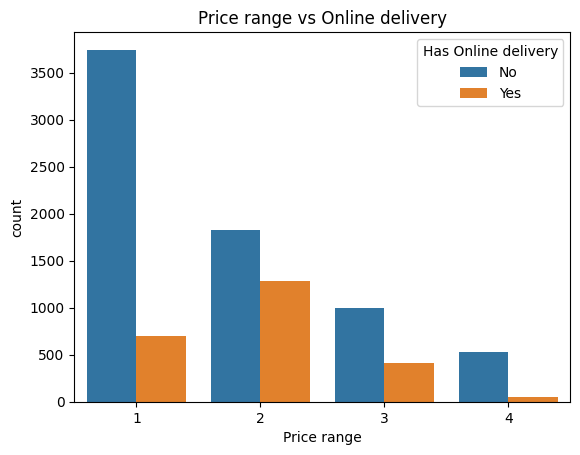

In [24]:
#Price range vs Online delivery
sns.countplot(x='Price range', hue='Has Online delivery', data=df)
plt.title("Price range vs Online delivery")
plt.show()

***Insight:***
*Mid-priced restuarants are likely to offer delivery.*

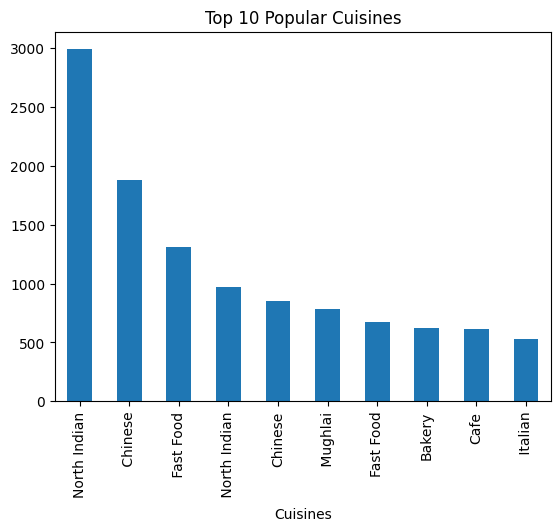

In [25]:
#Top 10 cuisines
cuisines = df['Cuisines'].str.split(',').explode()
top_cuisines = cuisines.value_counts().head(10)

top_cuisines.plot(kind = 'bar')
plt.title("Top 10 Popular Cuisines")
plt.show()

***Insights:***
*1. India has the highest number of restuarants.*

*2. Online delivery is not universal.*

*3. Cost doesn't strongly affect ratings.*

*4. User votes improve rating reliability.*

*5. Cuisine type influences popularity.*


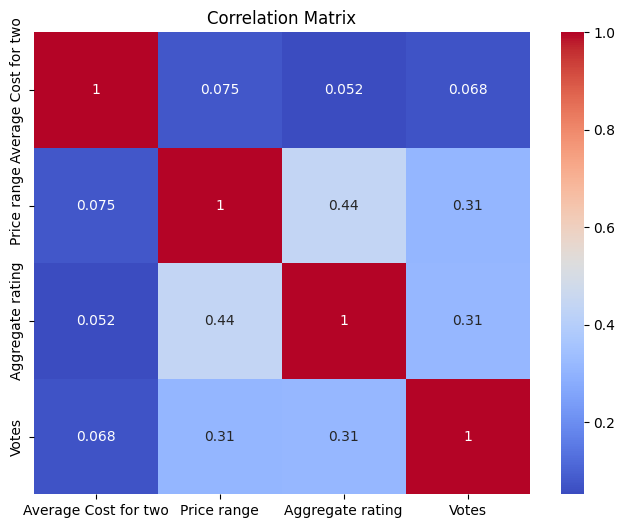

In [26]:
# COrrelation Heatmap

numeric_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

***Insight:***
*Restaurants in higher price ranges generally receive better ratings, while the actual cost for two has almost no impact on how customers rate a restaurant.*

In [27]:
#Top 10 Restuarants
top_restaurants = df.sort_values('Votes', ascending=False)[
    ['Restaurant Name', 'Votes', 'Aggregate rating']
].head(10)

print(top_restaurants)

                Restaurant Name  Votes  Aggregate rating
728                        Toit  10934               4.8
735                    Truffles   9667               4.7
3994           Hauz Khas Social   7931               4.3
2412                  Peter Cat   7574               4.3
739   AB's - Absolute Barbecues   6907               4.6
2414            Barbeque Nation   5966               4.9
743                 Big Brewsky   5705               4.5
2307  AB's - Absolute Barbecues   5434               4.9
736             The Black Pearl   5385               4.1
2411                      BarBQ   5288               4.2


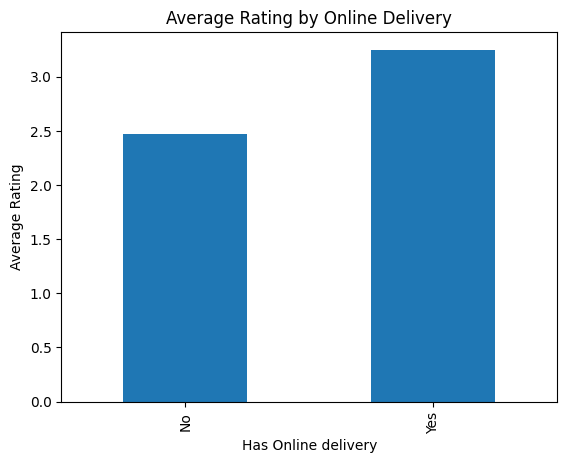

In [28]:
#Online Delivery Impact on Ratings
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()

delivery_rating.plot(kind='bar')
plt.title('Average Rating by Online Delivery')
plt.ylabel('Average Rating')
plt.show()

**Business Insight: Does online delivery improve customer satisfaction?**
*Yes, restaurants offering online delivery achieve noticeably higher average ratings, proving that convenience directly drives better customer satisfaction and engagement.*

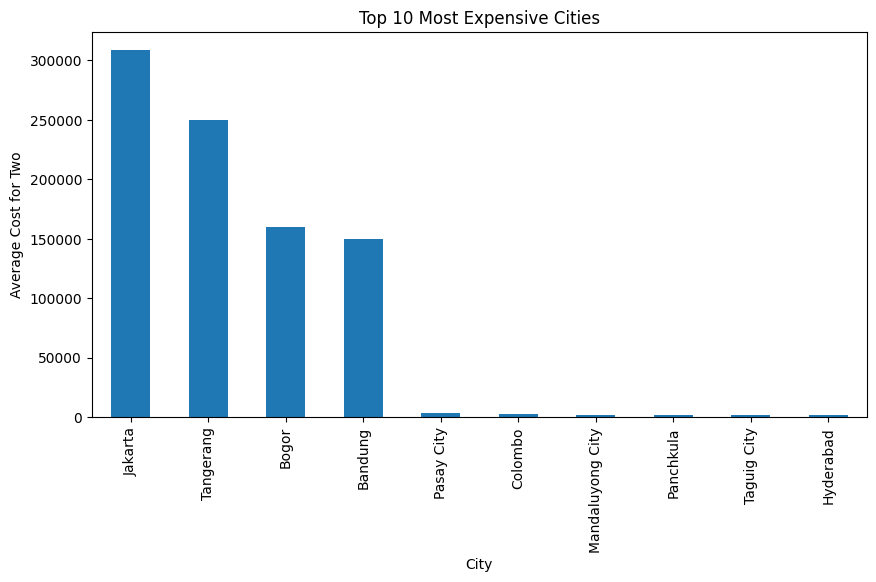

In [29]:
#Most Expensive Cities
city_cost = df.groupby('City')['Average Cost for two'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
city_cost.head(10).plot(kind='bar')
plt.title('Top 10 Most Expensive Cities')
plt.ylabel('Average Cost for Two')
plt.show()